# Similarity early-time model

## Load the simulations

In [ ]:
from ipynb_boilerplate import *
from crocodil.theory.system_a.early import EarlyTimeSimilarityModel
AGG = True
if AGG: configure_matplotlib(backend='Agg')
SAVE = True

SR = 0.2
PARAM_KEYS = ('Ra', 'Da')
PARAMS_FIXED = SYSTEM_A_REFERENCE.replace(sr=SR).remove(*PARAM_KEYS)

simulations_batch = GridSimulationFromNPZ.dict_from_dir_paths(
    PARAM_KEYS, 
    SIM_DIR_PATHS,
    ('c', 's'),
    ('f', 'mD', 'mC', 'uRMS'),
    PARAMS_FIXED,
    lazy=True,
    sorting=lambda d: dict(sorted(d.items(), reverse=False)),
)
save_fig = partial(
    save_figure, 
    dir_path=DIR_FIGS, 
    prefix='EarlySimilarity', 
    pickle=True,
    close=AGG,
    file_ext=('svg', 'pdf', 'png'),
) if SAVE else pass_anything

In [2]:
print('Before parameter batching')
for i in SIM_DIR_PATHS: print(i)
print('After parameter batching')
for i in simulations_batch.values(): print(i.dir_path)

Before parameter batching
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=1.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__8cdc0d7deee27009/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__f1e8b107b29abbbb/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__5e822ff46ee05fa4/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=1000.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__3823d90f6e03a6fd/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=500.0|Da=1.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__795c9d7125905bce/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=500.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__c4deca4f8fe27111/
./data__c_stabilization=None|c_limits=True/

## Select the simulations

In [3]:
Ra_target = 100.0
Da_targets = None
simulations = {
    (Ra, Da): v for (Ra, Da), v in simulations_batch.items()
    if include_prm(Ra, [Ra_target]) and include_prm(Da, Da_targets)
}

In [4]:
print('After parameter selection')
for i in simulations.values(): print(i.dir_path)

After parameter selection
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=1.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__8cdc0d7deee27009/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=10.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__f1e8b107b29abbbb/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=100.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__5e822ff46ee05fa4/
./data__c_stabilization=None|c_limits=True/t_stop=120.0__Ra=100.0|Da=1000.0|epsilon=0.01|zeta0=0.9|sr=0.2|cr=0.0|aspect=2.0|Nx=160|Ny=160__3823d90f6e03a6fd/


## Comparison of model with DNS

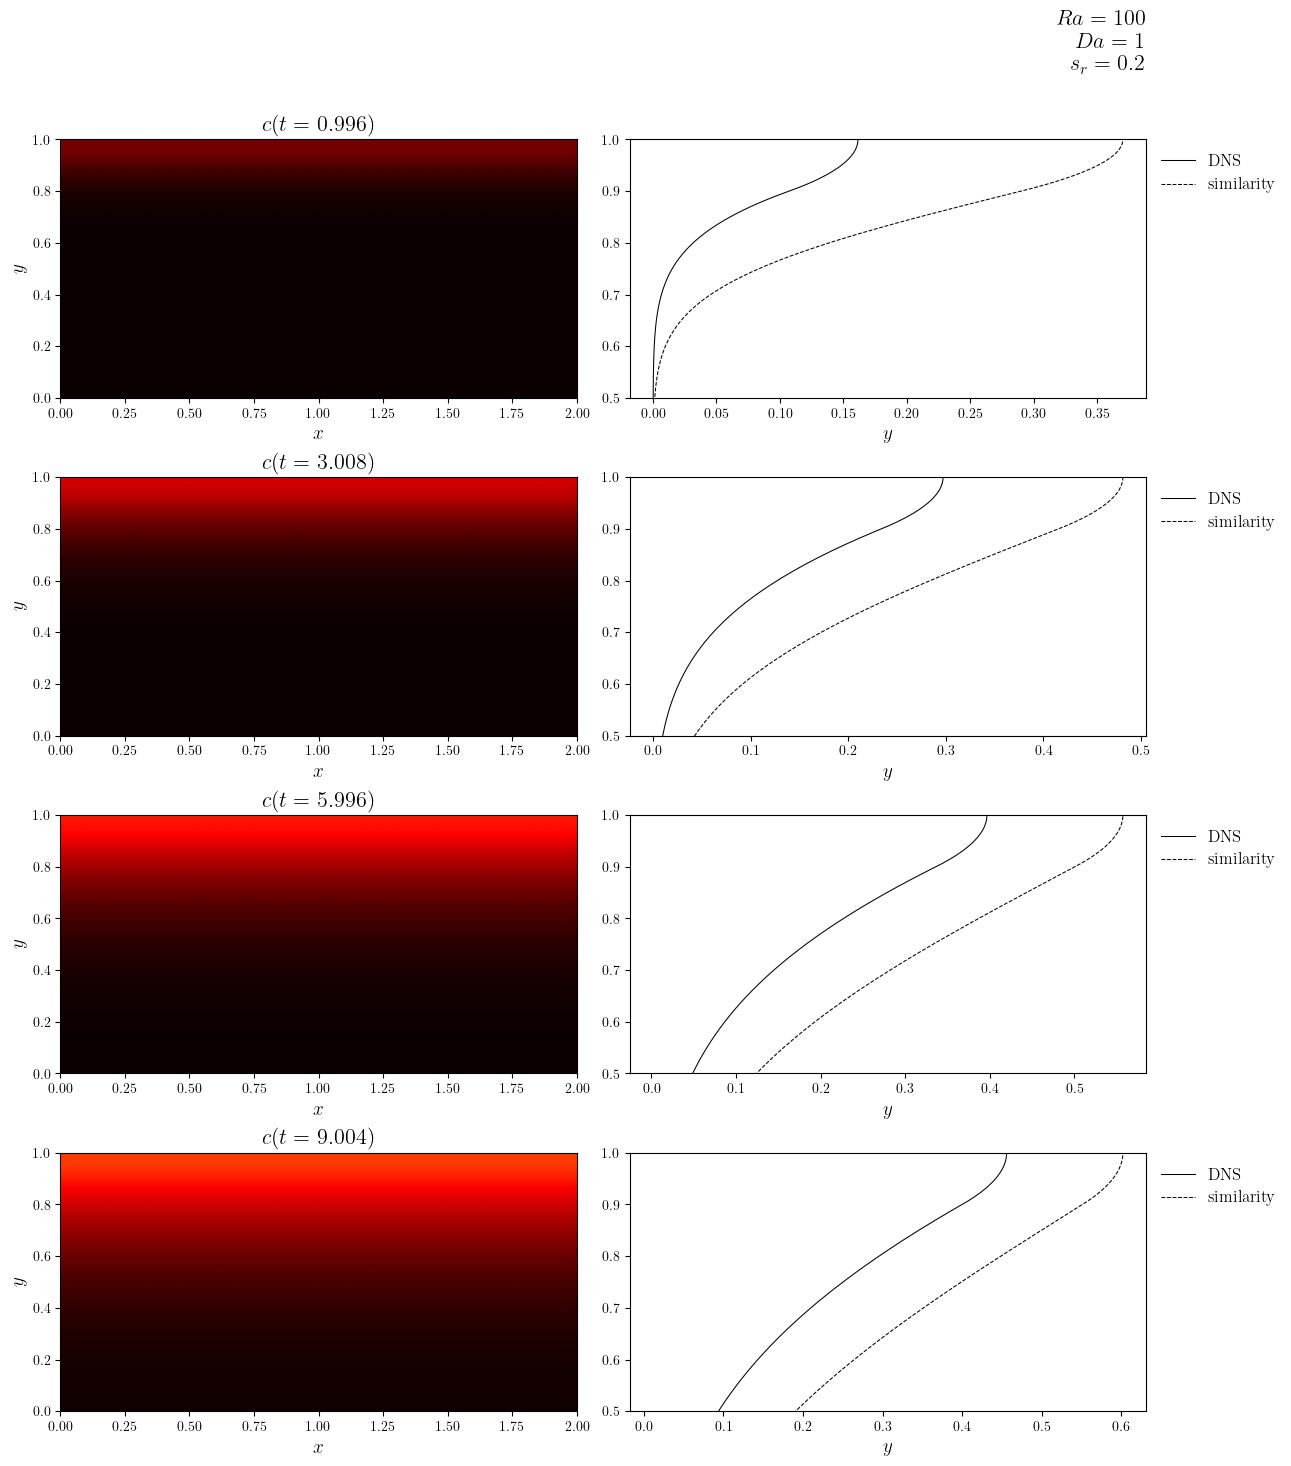

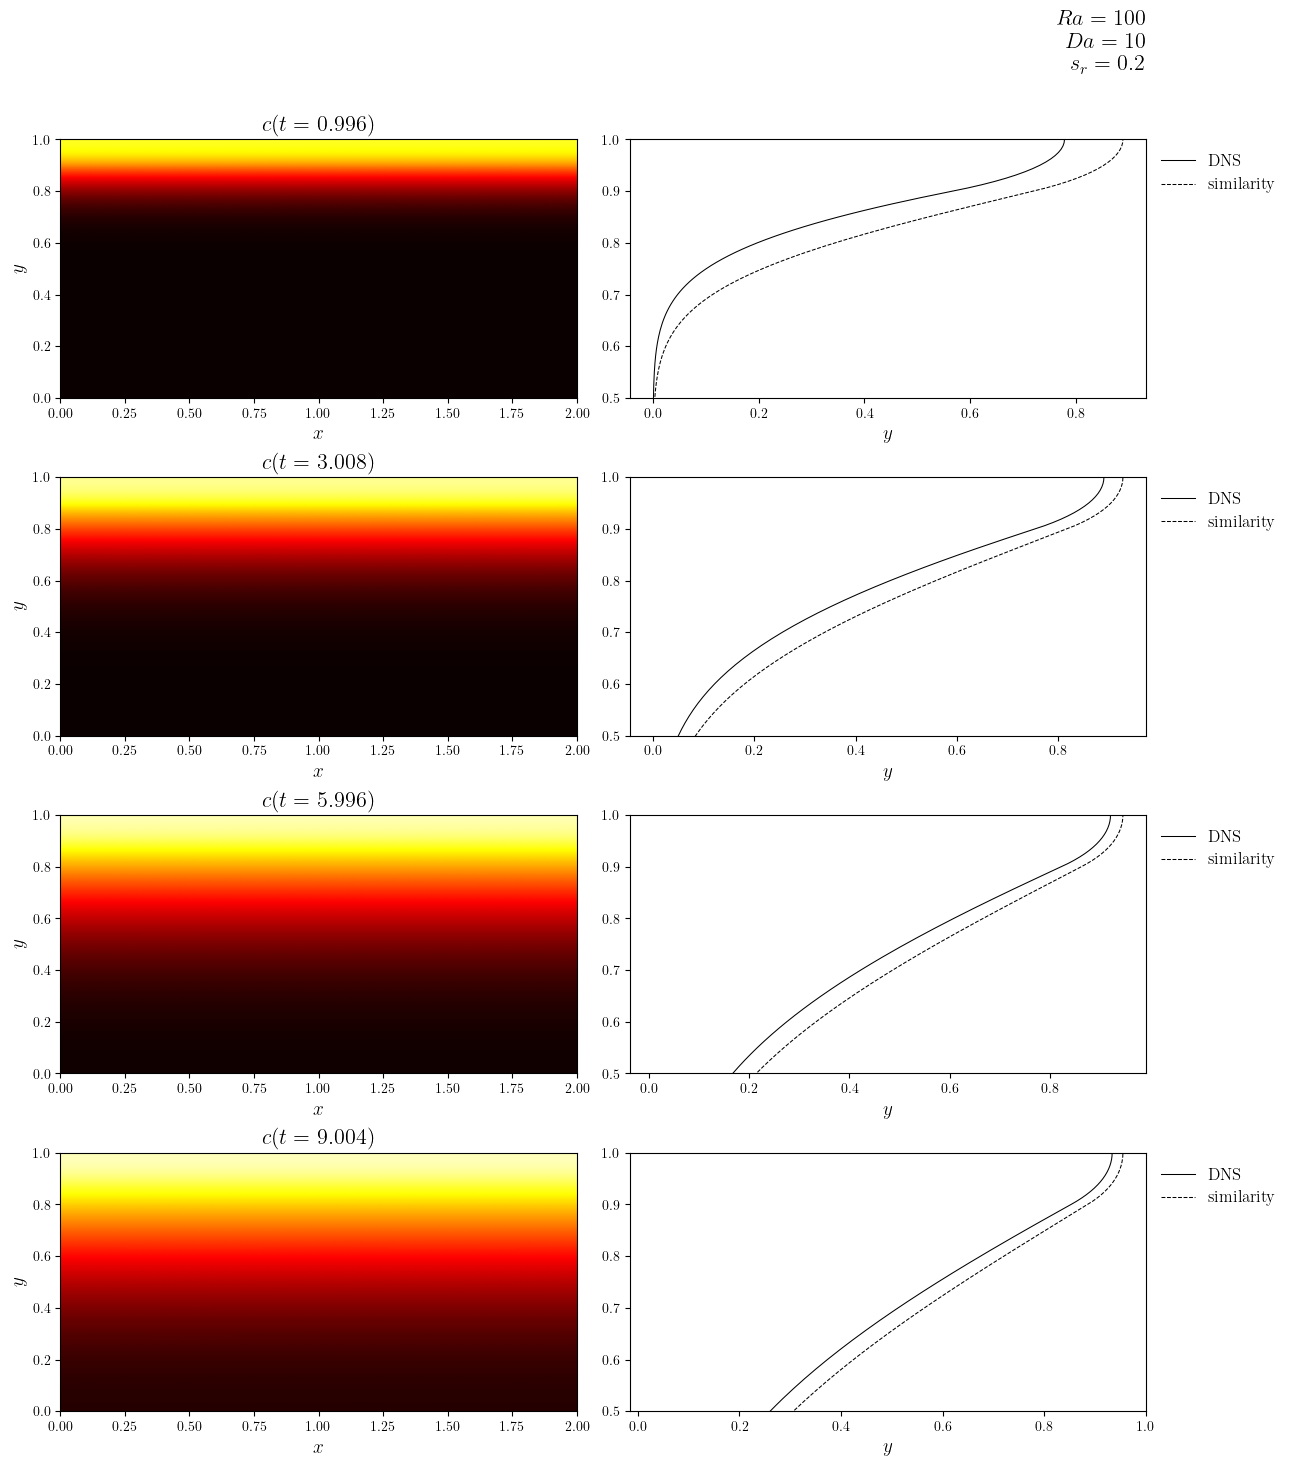

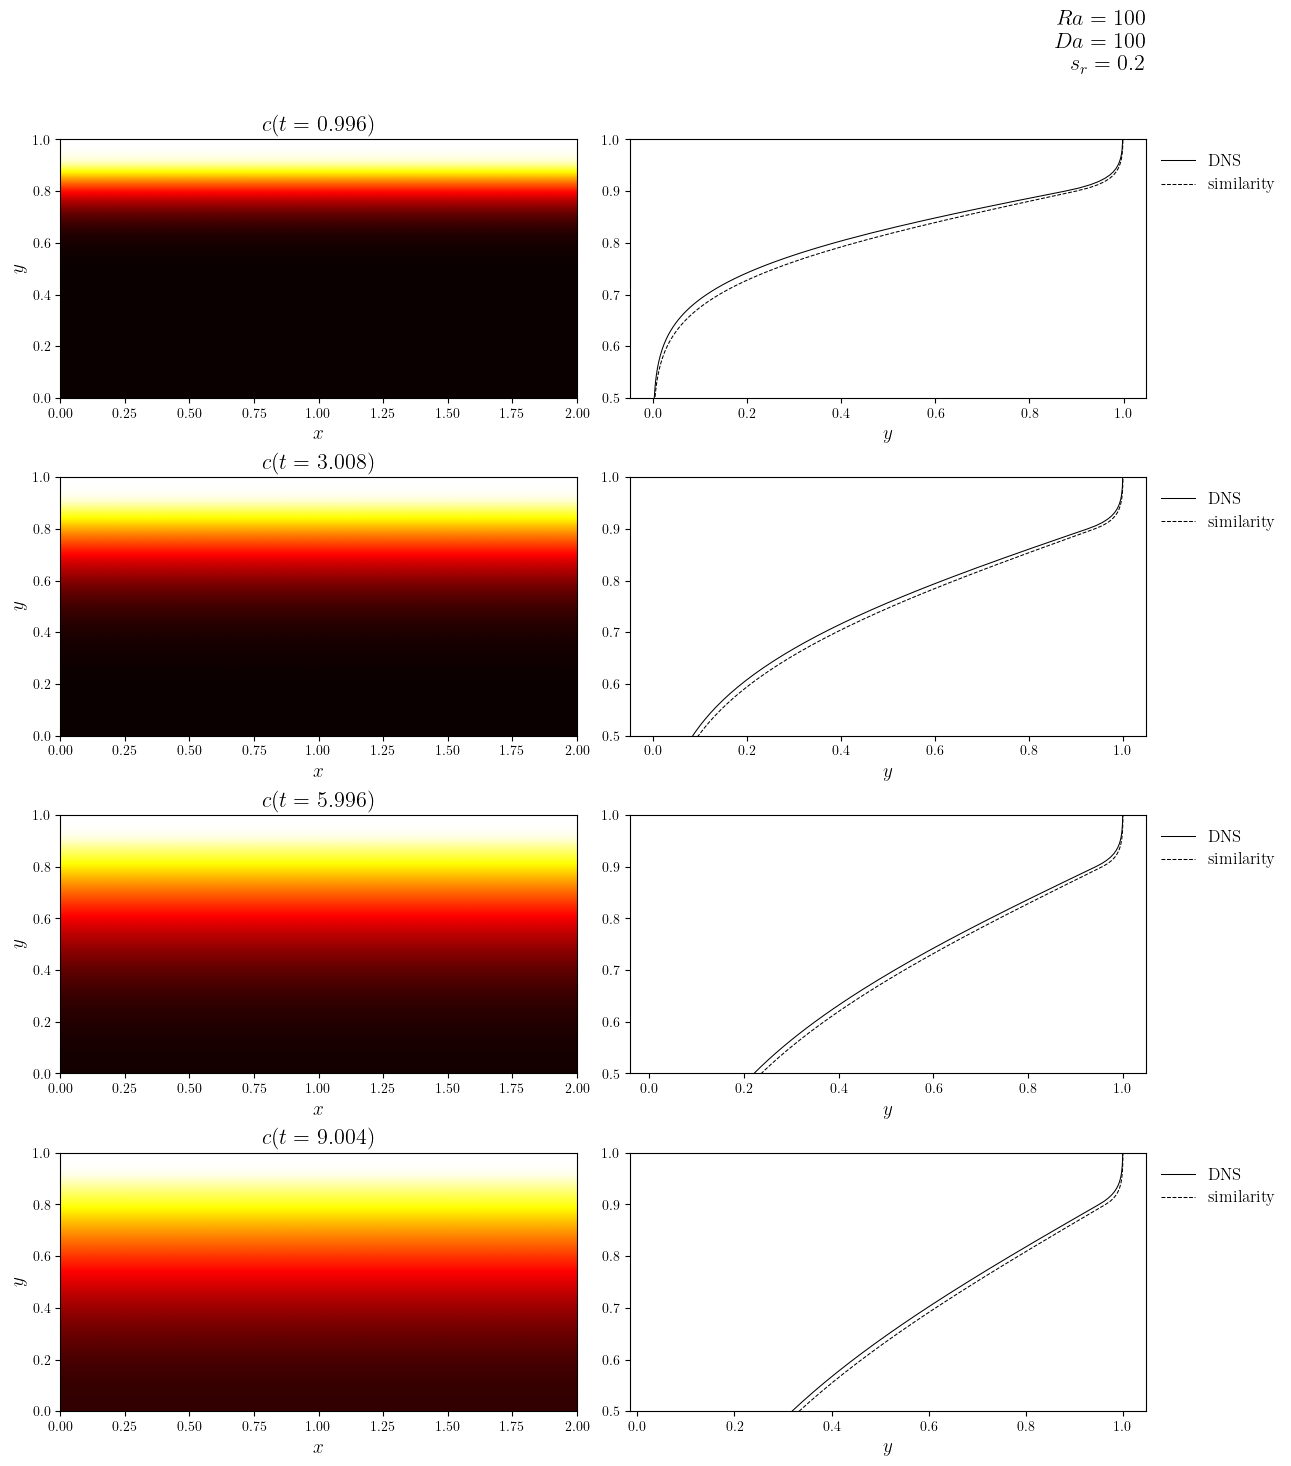

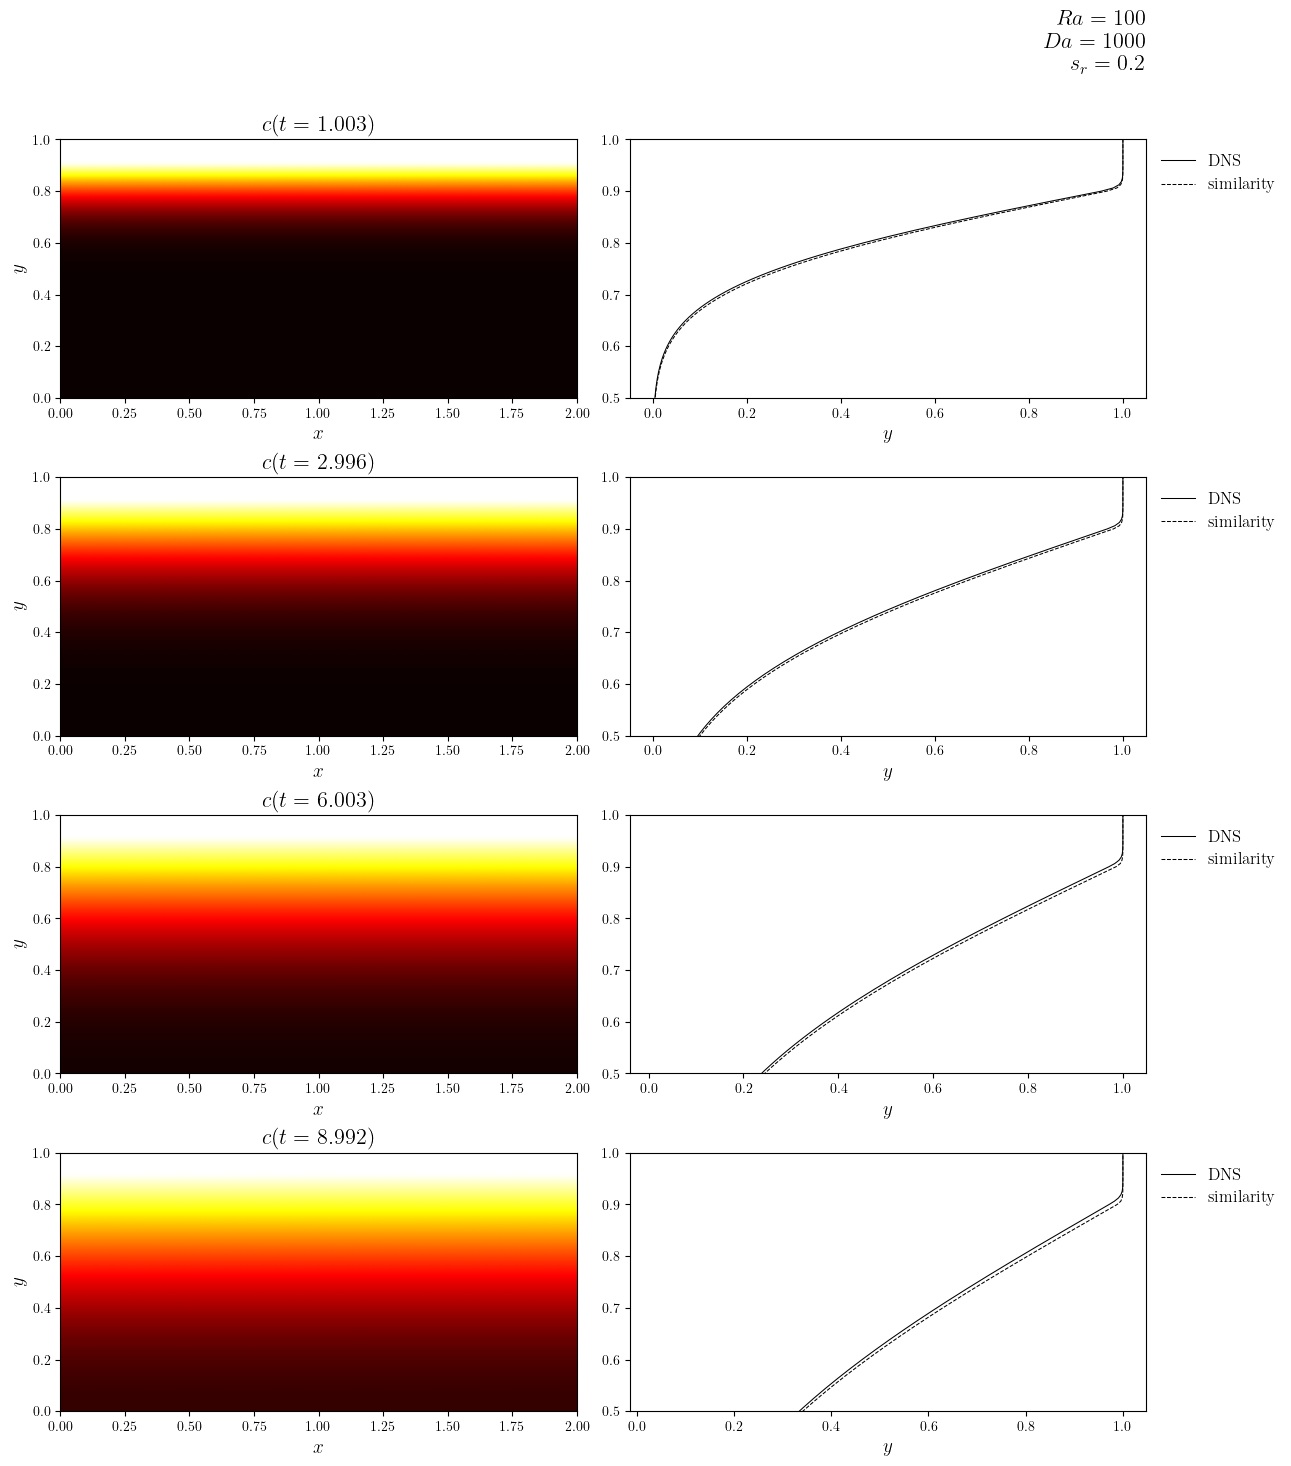

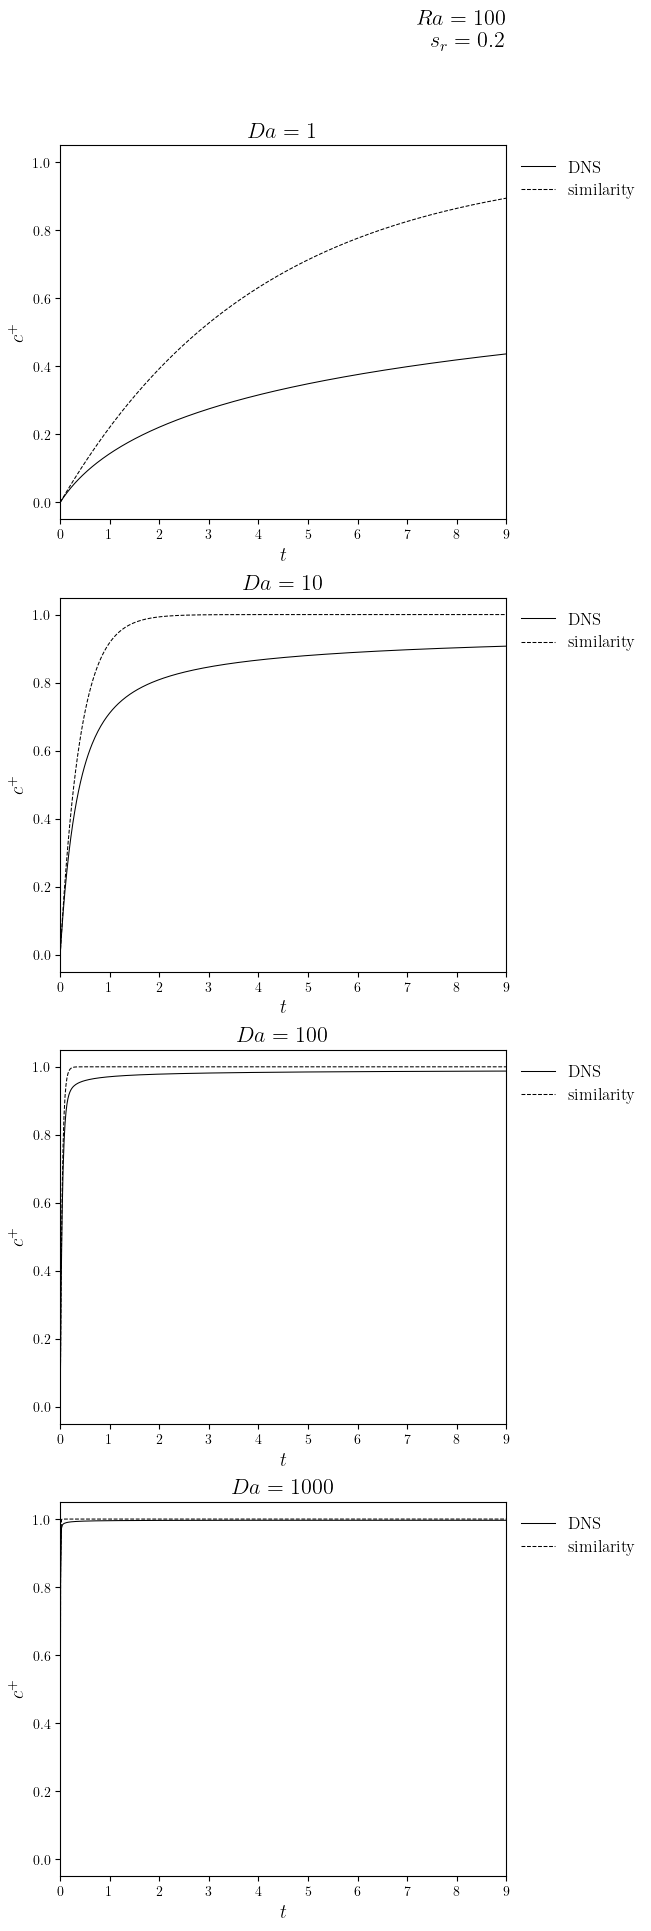

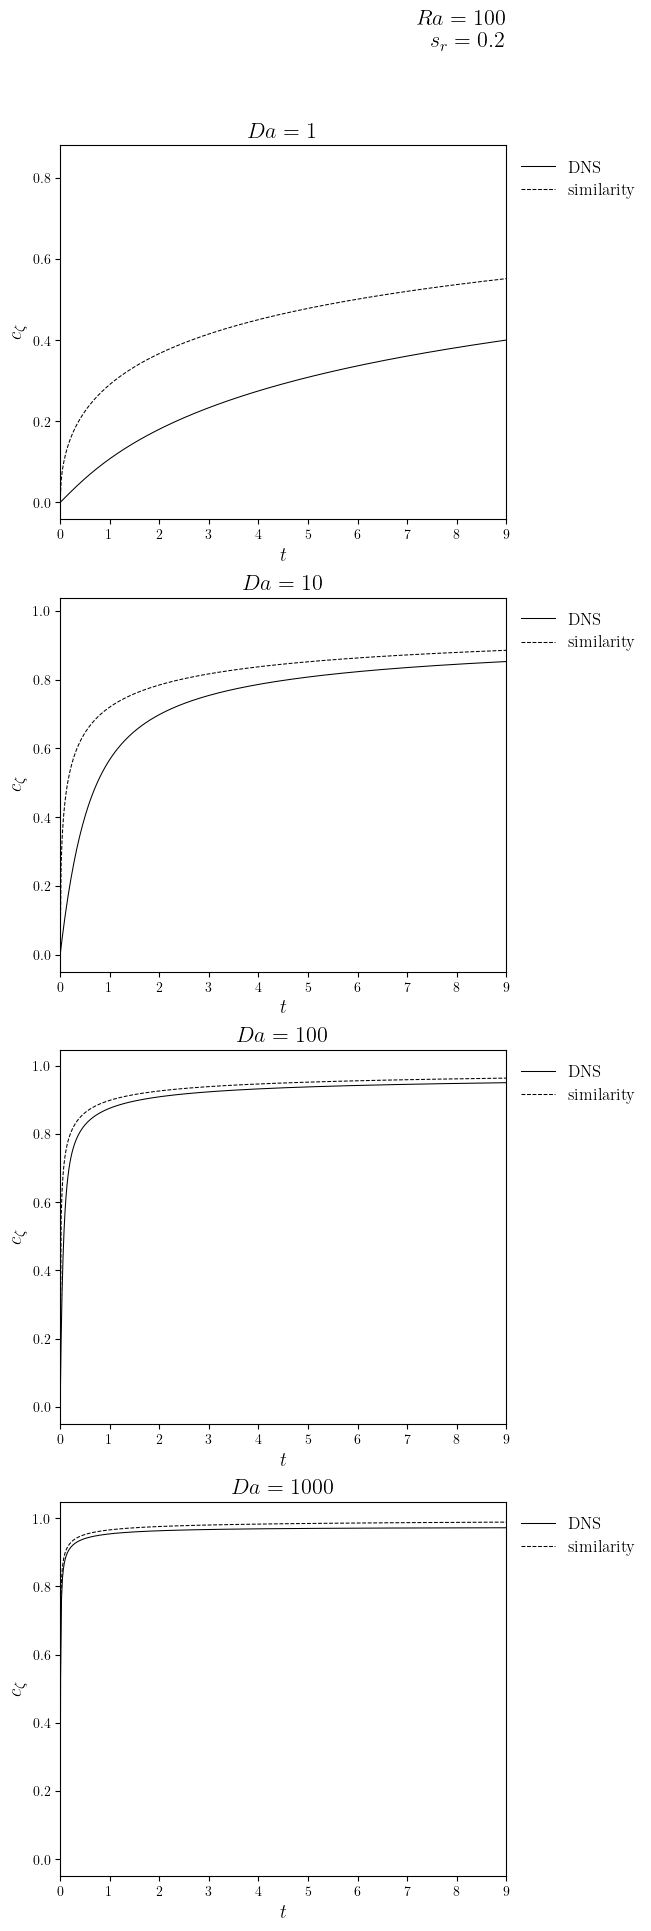

: 

In [ ]:
t_targets = (1.0, 3.0, 6.0, 9.0)
legend_labels = ['DNS', 'similarity']

cPlus_lines, cZeta_lines, line_titles = [], [], []

for (Ra, Da), sim in simulations.items():
    c = sim['c']
    zeta0, sr, cr = sim['zeta0', 'sr', 'cr']
    zeta0_index = as_index(c.mesh.y_axis, zeta0)
    slcPlus = slice(zeta0_index, None)
    asymp_model = EarlyTimeSimilarityModel(
        c.time_series, c.mesh.y_axis, 1/Ra, Da, zeta0, sr, cr, infty=False,
    )
    cPlus = NPyConstantSeries(
        average_grid(c.series, ('x', 'y'), (':', slcPlus)), c.time_series, 'cPlus',
    )
    cPlus_lines.append(
        [(cPlus.time_series, cPlus.value_series), (asymp_model.t, asymp_model.cPlus)]
    )
    cZeta = NPyConstantSeries(
        average_grid(c.series, 'x', (':', zeta0_index)), c.time_series, 'cZeta',
    )
    # cZeta_value_series = [np.mean(i.value[:, zeta0_index]) for i in c.series]
    cZeta_lines.append(
        [(cZeta.time_series, cZeta.value_series), (asymp_model.t, asymp_model.cZeta)]
    )
    line_titles.append(f"$Da={as_int_if_close(sim['Da'])}$")
    mfig, axs_main, _ = create_multifigure(
        n_rows=len(t_targets), n_cols=2,
        suptitle='\n'.join((
            f"$Ra={as_int_if_close(sim['Ra'])}$",
            f"$Da={as_int_if_close(sim['Da'])}$",
            f"$s_r={as_int_if_close(sim['sr'])}$",
        ))
    )
    for i, trg in enumerate(t_targets):
        time_index = as_index(c.time_series, trg)
        t_actual = c.time_series[time_index]
        cAvgX = average_grid(use_cache=True)(c.series[time_index], 'x') 
        cModel = (asymp_model.y, asymp_model.c[time_index])
        plot_colormap(
            mfig, 
            axs_main[2 * i], 
            c.series[time_index], 
            colorbar=False,
            title=f"$c(t={t_actual:.3f})$",
            vmin=0,
            vmax=1,
        )
        plot_line(
            mfig, 
            axs_main[2 * i + 1], 
            [cAvgX, cModel], 
            legend_labels=legend_labels, 
            flip=True,
            x_label='$y$',
            y_lims=(0.5, 1.0),
        )
    save_fig(f'Ra={Ra}_Da={Da}_sr={sr}_c')(mfig, file_ext=('pdf', 'png'))


mfig_cPlus, axs_cPlus, _ = create_multifigure(
    n_rows=len(simulations), n_cols=1,
    suptitle='\n'.join((
        f"$Ra={as_int_if_close(Ra_target)}$",
        f"$s_r={as_int_if_close(SR)}$",
    ))
)
for ax, ln, ttl in zip(axs_cPlus, cPlus_lines, line_titles, strict=True):
    plot_line(
        mfig_cPlus,
        ax,
        ln,
        x_label='$t$',
        y_label='$c^+$',
        title=ttl,
        legend_labels=legend_labels,
        x_lims=(0, max(t_targets)), #(0, 10 / asymp_model.Pi)
    )
save_fig(f'Da_Ra={Ra_target}_sr={SR}_cPlus')(mfig_cPlus)

mfig_cZeta, axs_cZeta, _ = create_multifigure(
    n_rows=len(simulations), n_cols=1,
    suptitle='\n'.join((
        f"$Ra={as_int_if_close(Ra_target)}$",
        f"$s_r={as_int_if_close(SR)}$",
    ))
)
for ax, ln, ttl in zip(axs_cZeta, cZeta_lines, line_titles, strict=True):
    plot_line(
        mfig_cZeta,
        ax,
        ln,
        x_label='$t$',
        y_label='$c_\zeta$',
        title=ttl,
        legend_labels=legend_labels,
        x_lims=(0, max(t_targets)),
    )
save_fig(f'Da_Ra={Ra_target}_sr={SR}_cZeta')(mfig_cZeta)
